In [ ]:
%pip install -r ./requirements.txt

In [25]:
import re
from pathlib import Path
import requests
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
# Q1:

BOOKS: dict[int, str] = {
    2701: "Moby Dick",
    1342: "Pride and Prejudice",
    84: "Frankenstein",
    1661: "The Adventures of Sherlock Holmes",
    11: "Alice's Adventures in Wonderland",
    74: "The Adventures of Tom Sawyer",
    98: "A Tale of Two Cities",
    1232: "The Prince",
    5200: "Metamorphosis",
    1952: "The Yellow Wallpaper",
}

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

def download_book(book_id: int) -> str | None:
    url: str = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
    response = requests.get(url = url, timeout=20)
    if response.status_code == 200:
        response.encoding = "utf-8"
        return response.text
    return None

def remove_boilerplate(book_name: str, book_text: str) -> str:
    start_pattern: str = fr"\*\*\* START OF THE PROJECT GUTENBERG EBOOK {book_name.upper()}.*?\*\*\*"
    end_pattern: str = fr"\*\*\* END OF THE PROJECT GUTENBERG EBOOK {book_name.upper()}.*?\*\*\*"
    book_text = re.sub(r"\r\n", "\n", book_text) # replaces all windows-style line-endings to unix-like
    start_match: re.Match[str] | None = re.search(start_pattern, book_text, flags=re.IGNORECASE | re.DOTALL)
    end_match: re.Match[str] | None = re.search(end_pattern, book_text, flags=re.IGNORECASE | re.DOTALL)
    start_index = start_match.end() if start_match is not None else 0
    end_index = end_match.start() if end_match is not None else len(book_text)
    book_text = book_text[start_index:end_index]
    return book_text.strip()

def write_book_to_file(book_id: int, text: str):
    path = DATA_DIR / f"{book_id}.txt"
    path.write_text(data = text, encoding="utf-8")
    print(f"Book: {BOOKS.get(book_id)} with id: {book_id}. File Size = {round(path.stat().st_size / 1024, 2)}kB. Beggining = {text[:100].replace("\n", "")}")

DOWNLOAD_BASE_URL = 'www.gutenberg.org/ebooks'
def download_books() -> dict[int, str]:
    book_dict: dict[int,str] = {}
    for book_id, book_name in BOOKS.items():
        result = download_book(book_id=book_id)
        if result is None:
            raise ValueError(f"failure during downloading of book {book_id}")
        text = remove_boilerplate(book_name=book_name, book_text=result)
        book_dict[book_id] = text
    return book_dict
        
        
book_dict: dict[str, int] = download_books()
for book_id, book_text in book_dict.items():
    write_book_to_file(book_id, book_text)


Book: Moby Dick
Sentences with 'monster': 49
- “And what thing soever besides cometh within the chaos of this monster’s mouth, be it beast, boat, or stone, down it goes all incontinently that foul great swallow of his, and perisheth in the bottomless gulf of his paunch.”
- “And whereas all the other things, whether beast or vessel, that enter into the dreadful gulf of this monster’s (whale’s) mouth, are immediately lost and swallowed up, the sea-gudgeon retires into it in great security, and there sleeps.”
- Being once pursued by a whale which he had wounded, he parried the assault for some time with a lance; but the furious monster at length rushed on the boat; himself and comrades only being preserved by leaping into the water when they saw the onset was inevitable.”

Book: Pride and Prejudice
Sentences with 'monster': 0

Book: Frankenstein
Sentences with 'monster': 31
- I started from my sleep with horror; a cold dew covered my forehead, my teeth chattered, and every limb became co

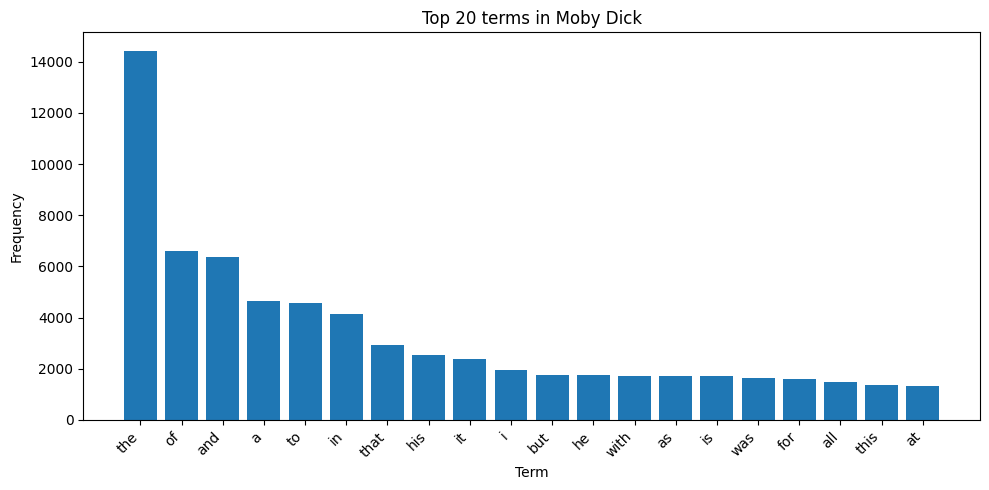

In [31]:
# Q2
# \b means it touches a word boundary
CONTRACTIONS = {
    r"\bdon't\b": "do not",
    r"\bcan't\b": "cannot",
    r"\bwon't\b": "will not",
    r"\bit's\b": "it is",
    r"\bi'm\b": "i am",
    r"\bi've\b": "i have",
    r"\bi'll\b": "i will",
    r"\bthat's\b": "that is",
    r"\bthere's\b": "there is",
    r"\bi'd\b": "i would"
}


def to_lower(book_text: str) -> str:
    return book_text.lower()

def normalize_contractions(book_text: str) -> str:
    for pattern, replacement in CONTRACTIONS.items():
        book_text = re.sub(pattern, replacement, book_text, flags=re.IGNORECASE)
    return book_text

def normalize_whitespaces(book_text: str) -> str:
    book_text = re.sub(r"\s+", " ", book_text)
    return book_text

def remove_special_characters(book_text: str) -> str:
    return re.sub(r"[^a-zA-Z\s]", "", book_text)

def find_ing_words(text: str) -> list[str]:
    return re.findall(r"\b[a-zA-Z]+ing\b", text)

def normalize_text(book_text: str) -> str:
    book_text = to_lower(book_text)
    book_text = normalize_whitespaces(book_text)
    book_text = normalize_contractions(book_text)
    book_text = remove_special_characters(book_text)
    return book_text

def extract_sentences_with_keyword(book_text: str, keyword: str) -> list[str]:
    pattern = rf"[^.!?]*\b{re.escape(keyword)}\b[^.!?]*[.!?][\"”’']?"
    sentences = re.findall(pattern, book_text, flags=re.IGNORECASE)
    return [normalize_whitespaces(sentence).strip() for sentence in sentences]

def find_words(book_text: str) -> list[str]:
    return re.findall(r"\b[a-zA-Z]+\b", book_text)

keyword = "monster"
for book_id, book_text in book_dict.items():
    sentences = extract_sentences_with_keyword(book_text, keyword)
    print(f"\nBook: {BOOKS.get(book_id)}")
    print(f"Sentences with '{keyword}': {len(sentences)}")
    for sentence in sentences[:3]:
        print("-", sentence)

print("\n")

for book_id, book_text in book_dict.items():
    book_text = normalize_text(book_text)
    words: list[str] = find_ing_words(text = book_text)
    print(f"Words ending with -ing in a book {BOOKS.get(book_id)}: {words[:10]}. Total {len(words)}.")

print("\n")

ing_frequency_records = []
for book_id, book_text in book_dict.items():
    book_text = normalize_text(book_text)
    ing_words = find_ing_words(book_text)
    ing_counts = Counter(ing_words)
    for word, frequency in ing_counts.most_common(20):
        ing_frequency_records.append({
            "book_id": book_id,
            "title": BOOKS.get(book_id),
            "word": word,
            "frequency": frequency
        })

word_frequency_records = []
for book_id, book_text in book_dict.items():
    normalized_text = normalize_text(book_text)
    words = find_words(normalized_text)
    word_counts = Counter(words)
    for word, frequency in word_counts.most_common(20):
        word_frequency_records.append({
            "book_id": book_id,
            "title": BOOKS.get(book_id),
            "word": word,
            "frequency": frequency
        })

word_frequency_df = pd.DataFrame(word_frequency_records)
word_frequency_df = word_frequency_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)
word_frequency_df.head(20)

def visualise_top_terms(book_id: int, num_terms: int):
    if num_terms < 1:
        raise ValueError("num_terms must be >= 1")
    selected_words_df = word_frequency_df[word_frequency_df["book_id"] == book_id].sort_values(by="frequency", ascending=False).head(num_terms)
    plt.figure(figsize=(10, 5))
    plt.bar(selected_words_df["word"], selected_words_df["frequency"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top {num_terms} terms in {BOOKS.get(book_id)}")
    plt.xlabel("Term")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

first_book_id = next(iter(BOOKS))
visualise_top_terms(first_book_id, num_terms=20)